# OpenSky Network ETL — Live Aircraft Data
This notebook ingests live aircraft data from the OpenSky API, performs ETL with pandas, and generates three visualizations: aircraft density map, flights by country, and speed distribution.

In [1]:
# Step 1: API Ingestion
import requests
import pandas as pd

url = "https://opensky-network.org/api/states/all"
response = requests.get(url)
data = response.json()

states = data.get("states", [])
len(states)

13473

### Raw JSON Structure
Each aircraft is represented as an array of fields. We convert this into a structured DataFrame.

In [2]:
# Step 2: Convert to DataFrame
columns = [
    "icao24", "callsign", "origin_country", "time_position", "last_contact",
    "longitude", "latitude", "baro_altitude", "on_ground", "velocity",
    "heading", "vertical_rate", "sensors", "geo_altitude", "squawk",
    "spi", "position_source"
]

df = pd.DataFrame(states, columns=columns)
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,39de4e,TVF63EC,France,1.783618e+09,1783618210,-0.3362,45.0815,10965.18,False,239.11,21.98,0.00,None,11498.58,1000,False,0
1,ab1644,UAL1637,United States,1.783618e+09,1783618039,-74.1850,40.6860,NaN,True,4.37,292.50,NaN,None,NaN,0223,False,0
2,aa3cbe,N759PA,United States,1.783618e+09,1783618209,-112.3075,41.6591,1889.76,False,43.66,134.05,-4.88,None,1973.58,None,False,0
3,ae1fa3,EVANS11,United States,1.783618e+09,1783618210,-105.2237,40.0145,1821.18,False,46.78,188.22,3.90,None,1882.14,None,False,0
4,a7250f,N56FA,United States,1.783618e+09,1783618210,-118.6769,34.1780,1432.56,False,49.91,178.82,0.00,None,1440.18,None,False,0


### ETL Steps
- Drop rows missing lat/long
- Convert timestamps
- Compute speed in km/h
- Categorize altitude bands

In [3]:
# Step 3: ETL Transformations
df = df.dropna(subset=["latitude", "longitude"])

df["time_position"] = pd.to_datetime(df["time_position"], unit="s", errors="coerce")
df["last_contact"] = pd.to_datetime(df["last_contact"], unit="s", errors="coerce")

df["speed_kmh"] = df["velocity"] * 3.6

def altitude_band(alt):
    if pd.isna(alt): return "unknown"
    if alt < 3000: return "low"
    if alt < 9000: return "medium"
    return "high"

df["altitude_band"] = df["baro_altitude"].apply(altitude_band)

df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,speed_kmh,altitude_band
0,39de4e,TVF63EC,France,2026-07-09 17:30:10,2026-07-09 17:30:10,-0.3362,45.0815,10965.18,False,239.11,21.98,0.00,None,11498.58,1000,False,0,860.796,high
1,ab1644,UAL1637,United States,2026-07-09 17:27:19,2026-07-09 17:27:19,-74.1850,40.6860,NaN,True,4.37,292.50,NaN,None,NaN,0223,False,0,15.732,unknown
2,aa3cbe,N759PA,United States,2026-07-09 17:30:09,2026-07-09 17:30:09,-112.3075,41.6591,1889.76,False,43.66,134.05,-4.88,None,1973.58,None,False,0,157.176,low
3,ae1fa3,EVANS11,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-105.2237,40.0145,1821.18,False,46.78,188.22,3.90,None,1882.14,None,False,0,168.408,low
4,a7250f,N56FA,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-118.6769,34.1780,1432.56,False,49.91,178.82,0.00,None,1440.18,None,False,0,179.676,low


In [16]:
# Step X: Dynamic Country Filter

# Step X: Dynamic Country Filter (Interactive)

# Ask the user which country they want to filter
country = input("Enter a country name to filter aircraft by (e.g., United States, Germany, India): ")

# Filter the DataFrame
df_country = df[df["origin_country"].str.lower() == country.lower()].copy()

print(f"\nTotal aircraft from {country}: {len(df_country)}\n")
df_country.head()


Enter a country name to filter aircraft by (e.g., United States, Germany, India):  United States



Total aircraft from United States: 7637



,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,speed_kmh,altitude_band
1,ab1644,UAL1637,United States,2026-07-09 17:27:19,2026-07-09 17:27:19,-74.1850,40.6860,NaN,True,4.37,292.50,NaN,None,NaN,0223,False,0,15.732,unknown
2,aa3cbe,N759PA,United States,2026-07-09 17:30:09,2026-07-09 17:30:09,-112.3075,41.6591,1889.76,False,43.66,134.05,-4.88,None,1973.58,None,False,0,157.176,low
3,ae1fa3,EVANS11,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-105.2237,40.0145,1821.18,False,46.78,188.22,3.90,None,1882.14,None,False,0,168.408,low
4,a7250f,N56FA,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-118.6769,34.1780,1432.56,False,49.91,178.82,0.00,None,1440.18,None,False,0,179.676,low
14,ab6fdd,AAL1769,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-107.2784,35.7290,11582.40,False,224.85,244.96,0.00,None,12313.92,3361,False,0,809.460,high


In [21]:
# Step 4: Export ETL Output
df.to_csv("opensky_etl_output.csv", index=False)
df.head()

,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,speed_kmh,altitude_band
0,39de4e,TVF63EC,France,2026-07-09 17:30:10,2026-07-09 17:30:10,-0.3362,45.0815,10965.18,False,239.11,21.98,0.00,None,11498.58,1000,False,0,860.796,high
1,ab1644,UAL1637,United States,2026-07-09 17:27:19,2026-07-09 17:27:19,-74.1850,40.6860,NaN,True,4.37,292.50,NaN,None,NaN,0223,False,0,15.732,unknown
2,aa3cbe,N759PA,United States,2026-07-09 17:30:09,2026-07-09 17:30:09,-112.3075,41.6591,1889.76,False,43.66,134.05,-4.88,None,1973.58,None,False,0,157.176,low
3,ae1fa3,EVANS11,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-105.2237,40.0145,1821.18,False,46.78,188.22,3.90,None,1882.14,None,False,0,168.408,low
4,a7250f,N56FA,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-118.6769,34.1780,1432.56,False,49.91,178.82,0.00,None,1440.18,None,False,0,179.676,low


### Step X: Filter aircraft by country

In [12]:
# Step X: Filter aircraft by country

# User-defined country filter
country = "United States"   # <-- change this to any country
# country = "France" 

df_country = df[df["origin_country"] == country].copy()

print(f"Total aircraft from {country}: {len(df_country)}")
df_country.head()


Total aircraft from United States: 7637


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,sensors,geo_altitude,squawk,spi,position_source,speed_kmh,altitude_band
1,ab1644,UAL1637,United States,2026-07-09 17:27:19,2026-07-09 17:27:19,-74.1850,40.6860,NaN,True,4.37,292.50,NaN,None,NaN,0223,False,0,15.732,unknown
2,aa3cbe,N759PA,United States,2026-07-09 17:30:09,2026-07-09 17:30:09,-112.3075,41.6591,1889.76,False,43.66,134.05,-4.88,None,1973.58,None,False,0,157.176,low
3,ae1fa3,EVANS11,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-105.2237,40.0145,1821.18,False,46.78,188.22,3.90,None,1882.14,None,False,0,168.408,low
4,a7250f,N56FA,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-118.6769,34.1780,1432.56,False,49.91,178.82,0.00,None,1440.18,None,False,0,179.676,low
14,ab6fdd,AAL1769,United States,2026-07-09 17:30:09,2026-07-09 17:30:10,-107.2784,35.7290,11582.40,False,224.85,244.96,0.00,None,12313.92,3361,False,0,809.460,high


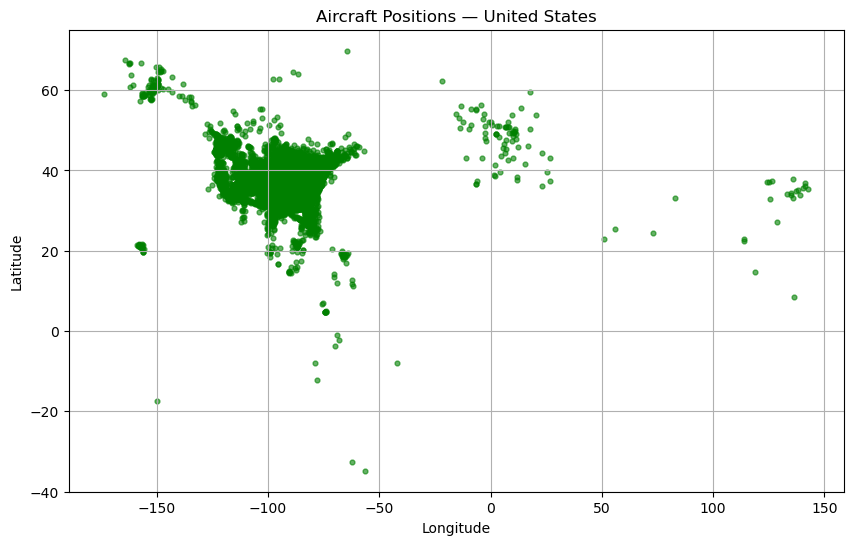

In [13]:
# Visualization: Aircraft positions for selected country

if df_country.empty:
    print(f"No aircraft found for {country}. Try another country.")
else:
    plt.figure(figsize=(10,6))
    plt.scatter(df_country["longitude"], df_country["latitude"], s=12, alpha=0.6, color="green")
    plt.title(f"Aircraft Positions — {country}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()


## Visualization A — Aircraft Density Map (Scatter Plot)

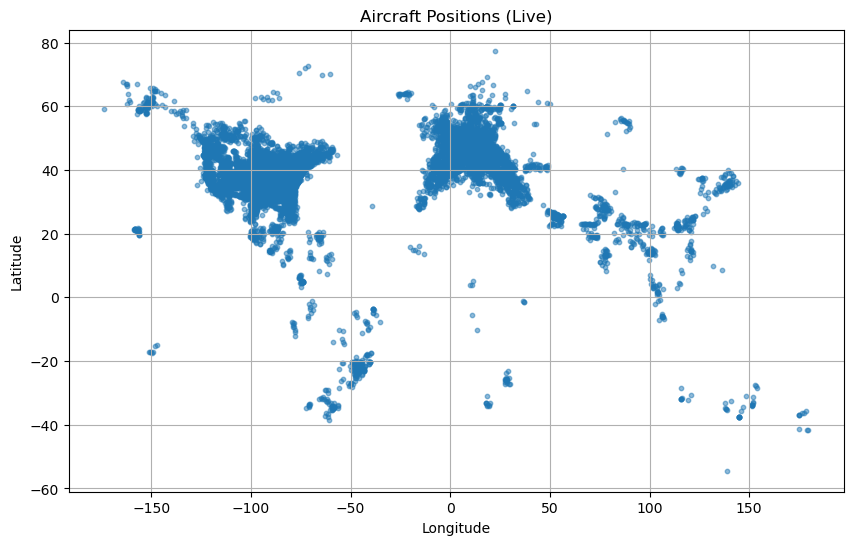

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df["longitude"], df["latitude"], s=10, alpha=0.5)
plt.title("Aircraft Positions (Live)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

## Visualization B — Flights by Origin Country

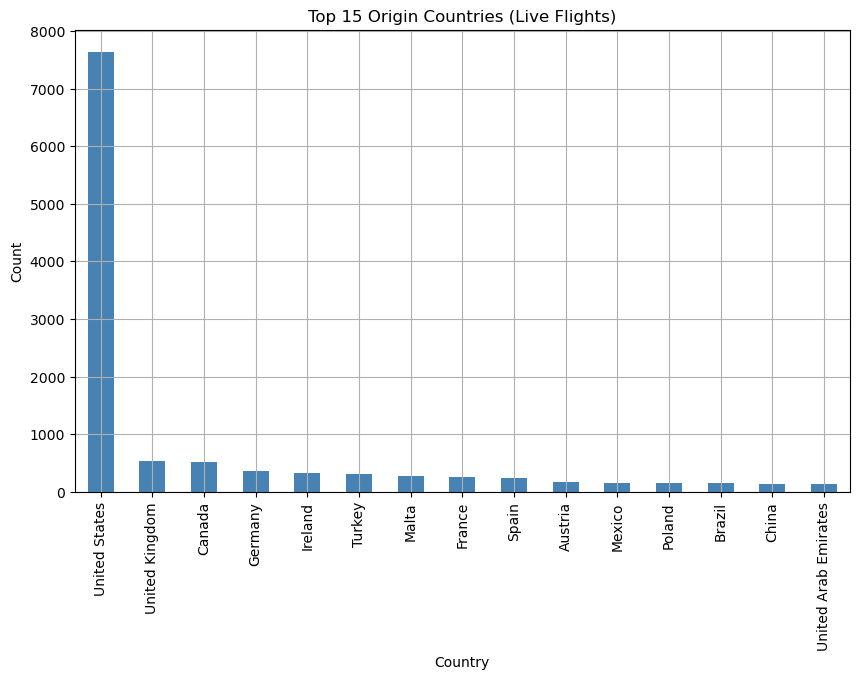

In [6]:
country_counts = df["origin_country"].value_counts().head(15)

plt.figure(figsize=(10,6))
country_counts.plot(kind="bar", color="steelblue")
plt.title("Top 15 Origin Countries (Live Flights)")
plt.xlabel("Country")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Visualization C — Aircraft Speed Distribution

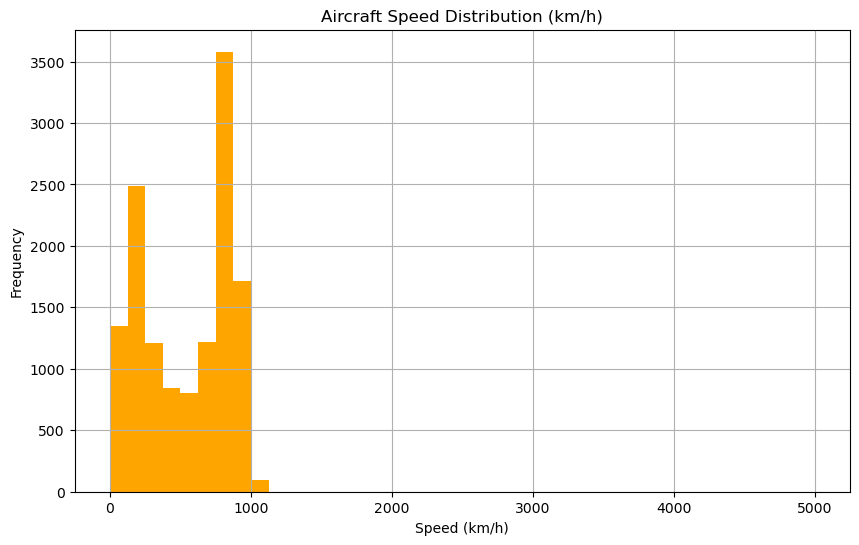

In [7]:
plt.figure(figsize=(10,6))
df["speed_kmh"].dropna().plot(kind="hist", bins=40, color="orange")
plt.title("Aircraft Speed Distribution (km/h)")
plt.xlabel("Speed (km/h)")
plt.grid(True)
plt.show()